# 03 Dissertation figures from W/O landscape tables

This notebook reproduces core dissertation-associated summary figures and tables from the processed W/O genotype landscape files.

The notebook starts from the archived dissertation-associated landscape tables and generates summary outputs for:

- mutational-load trends
- library-level enrichment summaries
- library-to-library reproducibility/correlation
- Pos-vs-Neg `ddelta` volcano source summaries

More specialized 3D landscape, network, path, and collaborator/model-comparison analyses are handled separately.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy.stats import pearsonr, mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "figures" / "dissertation"
CONFIG_PATH = PROJECT_ROOT / "config" / "analysis_config.yml"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

EPSILON = float(config["epsilon"])
MIN_SAMPLE_TOTAL_UMI = int(config["min_sample_total_umi"])
DDELTA_NEGATIVE_CUTOFF = float(config["ddelta_negative_cutoff"])
DDELTA_POSITIVE_CUTOFF = float(config["ddelta_positive_cutoff"])
QVALUE_CUTOFF = float(config["qvalue_cutoff"])

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Checkpoint output:", CHECKPOINT_DIR)
print("Figure output:", FIGURE_DIR)
print("Config path:", CONFIG_PATH)
print("EPSILON:", EPSILON)
print("Configured MIN_SAMPLE_TOTAL_UMI:", MIN_SAMPLE_TOTAL_UMI)
print("DDELTA_NEGATIVE_CUTOFF:", DDELTA_NEGATIVE_CUTOFF)
print("DDELTA_POSITIVE_CUTOFF:", DDELTA_POSITIVE_CUTOFF)
print("QVALUE_CUTOFF:", QVALUE_CUTOFF)

Project root: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape
Processed data: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/data/processed
Checkpoint output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/outputs/checkpoints
Figure output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/figures/dissertation
Config path: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/config/analysis_config.yml
EPSILON: 1e-06
Configured MIN_SAMPLE_TOTAL_UMI: 0
DDELTA_NEGATIVE_CUTOFF: -1.0
DDELTA_POSITIVE_CUTOFF: 1.0
QVALUE_CUTOFF: 0.05


In [2]:
wo_counts = pd.read_csv(PROCESSED_DIR / "wo_counts.csv")
landscape = pd.read_csv(PROCESSED_DIR / "WO_landscape_per_library.csv")
landscape_pvalues = pd.read_csv(PROCESSED_DIR / "WO_landscape_with_pvalues.csv")
volcano_source = pd.read_csv(PROCESSED_DIR / "WO_landscape_ddelta_posneg_volcano_source.csv")

print("wo_counts:", wo_counts.shape)
print("landscape:", landscape.shape)
print("landscape_pvalues:", landscape_pvalues.shape)
print("volcano_source:", volcano_source.shape)

print("\nlandscape columns:")
print(list(landscape.columns))

print("\nlandscape_pvalues columns:")
print(list(landscape_pvalues.columns))

print("\nvolcano_source columns:")
print(list(volcano_source.columns))

wo_counts: (5451, 6)
landscape: (768, 11)
landscape_pvalues: (768, 23)
volcano_source: (768, 16)

landscape columns:
['library_id', 'wo', 'Neg', 'Pos', 'Pre', 'log2fc_pos_pre', 'log2fc_neg_pre', 'delta_pos', 'delta_neg', 'mut_count', 'ddelta']

landscape_pvalues columns:
['library_id', 'wo', 'Neg', 'Pos', 'Pre', 'log2fc_pos_pre', 'log2fc_neg_pre', 'delta_pos', 'delta_neg', 'mut_count', 'ddelta', 'count_pre', 'count_pos', 'count_neg', 'p_pos_pre', 'p_neg_pre', 'p_pos_neg', 'q_pos_pre', 'q_neg_pre', 'q_pos_neg', 'p_pos_pre_safe', 'neglog10_p', 'neglog10_p_capped']

volcano_source columns:
['library_id', 'wo', 'Neg', 'Pos', 'Pre', 'log2fc_pos_pre', 'log2fc_neg_pre', 'delta_pos', 'delta_neg', 'mut_count', 'ddelta', 'p_pos_neg', 'q_pos_neg', 'p_pos_neg_safe', 'neglog10_p_pos_neg', 'category']


In [3]:
assert landscape.shape[0] == 3 * 256, "Expected 3 libraries x 256 genotypes."
assert landscape["wo"].str.len().eq(8).all(), "All W/O genotypes should have length 8."
assert set(landscape["library_id"]) == {1, 2, 3}, "Expected libraries 1, 2, and 3."

assert landscape_pvalues.shape[0] == 3 * 256, "Expected p-value table to have 768 rows."
assert volcano_source.shape[0] == 3 * 256, "Expected volcano source table to have 768 rows."

landscape_coverage = (
    landscape
    .groupby("library_id", as_index=False)
    .agg(
        n_genotypes=("wo", "nunique"),
        n_rows=("wo", "size")
    )
)

assert landscape_coverage["n_genotypes"].eq(256).all(), (
    "Each library should contain 256 genotypes."
)

landscape_coverage

,library_id,n_genotypes,n_rows
0,1,256,256
1,2,256,256
2,3,256,256


In [4]:
library_summary = (
    landscape
    .groupby("library_id", as_index=False)
    .agg(
        mean_log2fc_pos_pre=("log2fc_pos_pre", "mean"),
        sd_log2fc_pos_pre=("log2fc_pos_pre", "std"),
        median_log2fc_pos_pre=("log2fc_pos_pre", "median"),
        min_log2fc_pos_pre=("log2fc_pos_pre", "min"),
        max_log2fc_pos_pre=("log2fc_pos_pre", "max"),
        mean_log2fc_neg_pre=("log2fc_neg_pre", "mean"),
        sd_log2fc_neg_pre=("log2fc_neg_pre", "std"),
        median_log2fc_neg_pre=("log2fc_neg_pre", "median"),
        min_log2fc_neg_pre=("log2fc_neg_pre", "min"),
        max_log2fc_neg_pre=("log2fc_neg_pre", "max"),
        mean_ddelta=("ddelta", "mean"),
        sd_ddelta=("ddelta", "std"),
        median_ddelta=("ddelta", "median"),
        min_ddelta=("ddelta", "min"),
        max_ddelta=("ddelta", "max"),
        n_genotypes=("wo", "size")
    )
)

library_summary.to_csv(
    CHECKPOINT_DIR / "dissertation_library_summary.csv",
    index=False
)

library_summary

,library_id,mean_log2fc_pos_pre,sd_log2fc_pos_pre,median_log2fc_pos_pre,min_log2fc_pos_pre,max_log2fc_pos_pre,mean_log2fc_neg_pre,sd_log2fc_neg_pre,median_log2fc_neg_pre,min_log2fc_neg_pre,max_log2fc_neg_pre,mean_ddelta,sd_ddelta,median_ddelta,min_ddelta,max_ddelta,n_genotypes
0,1,-0.781064,1.841111,-0.400299,-6.988549,2.677817,-0.147501,0.774948,-0.146130,-2.617260,2.528625,-0.633562,1.628712,-0.295619,-7.149398,3.575571,256
1,2,-0.528008,1.666116,-0.170424,-6.261104,2.534916,-0.123556,0.579552,-0.120645,-2.469786,1.456478,-0.404452,1.781618,-0.000091,-5.986312,4.770095,256
2,3,-0.139517,0.842288,-0.128351,-2.781378,2.864940,-0.283409,1.048862,-0.176338,-4.603787,2.921981,0.143892,1.302523,0.096536,-2.871160,5.298167,256


## Replicate-level genotype frequency correlation

This section reproduces the replicate-level genotype frequency correlation heatmap using `wo_counts.csv`.

Each sequencing sample is represented as a 256-genotype frequency vector. Pearson correlations are calculated between sample-level genotype frequency profiles.

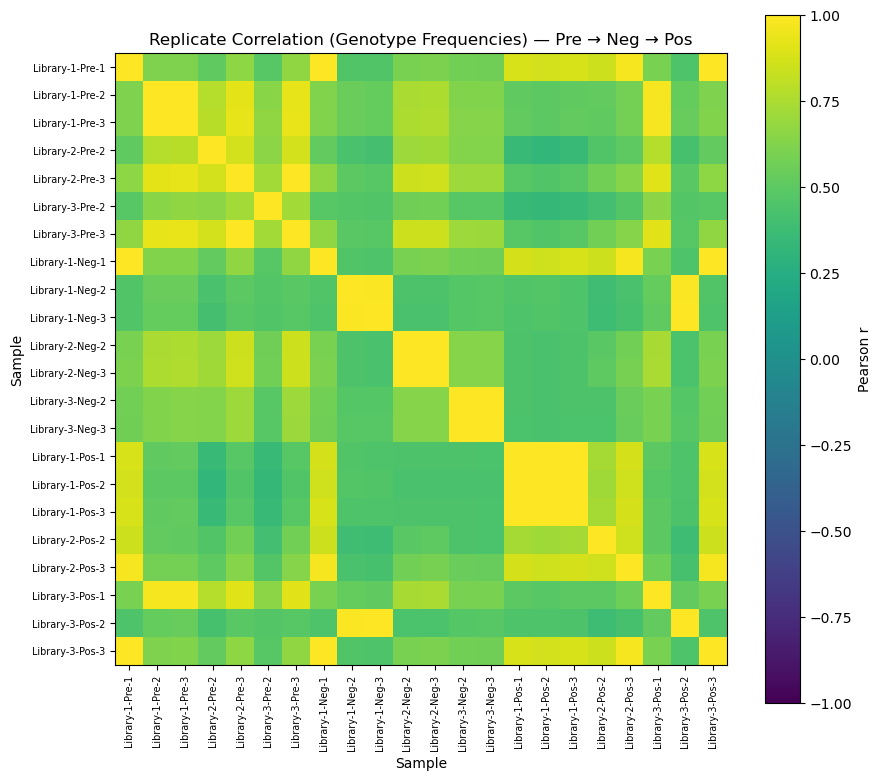

sample,Library-1-Pre-1,Library-1-Pre-2,Library-1-Pre-3,Library-2-Pre-2,Library-2-Pre-3,Library-3-Pre-2,Library-3-Pre-3,Library-1-Neg-1,Library-1-Neg-2,Library-1-Neg-3,...,Library-3-Neg-2,Library-3-Neg-3,Library-1-Pos-1,Library-1-Pos-2,Library-1-Pos-3,Library-2-Pos-2,Library-2-Pos-3,Library-3-Pos-1,Library-3-Pos-2,Library-3-Pos-3
sample,,,,,,,,,,,,,,,,,,,,,
Library-1-Pre-1,1.000000,0.614573,0.616908,0.514348,0.662584,0.478036,0.664758,0.999644,0.457347,0.454144,...,0.572641,0.567288,0.876647,0.862484,0.877996,0.849895,0.975400,0.595671,0.453044,0.999729
Library-1-Pre-2,0.614573,1.000000,0.993159,0.779776,0.920962,0.647779,0.923482,0.619917,0.539304,0.524228,...,0.623538,0.621452,0.513488,0.494848,0.513157,0.516544,0.584532,0.970233,0.530064,0.616083
Library-1-Pre-3,0.616908,0.993159,1.000000,0.788741,0.929603,0.665459,0.930709,0.622603,0.544176,0.529540,...,0.635321,0.633944,0.516406,0.498291,0.515752,0.512625,0.585673,0.976517,0.536050,0.618610
Library-2-Pre-2,0.514348,0.779776,0.788741,1.000000,0.861715,0.649449,0.865545,0.520610,0.424040,0.410727,...,0.628367,0.626694,0.350484,0.327556,0.351312,0.457768,0.503519,0.780237,0.415796,0.516020
Library-2-Pre-3,0.662584,0.920962,0.929603,0.861715,1.000000,0.719044,0.998532,0.667946,0.496263,0.483846,...,0.705875,0.703212,0.478951,0.458488,0.478712,0.574315,0.636636,0.905309,0.489974,0.664039
Library-3-Pre-2,0.478036,0.647779,0.665459,0.649449,0.719044,1.000000,0.719393,0.483361,0.460965,0.459623,...,0.480577,0.482281,0.347256,0.332262,0.345701,0.404128,0.461716,0.654085,0.463991,0.478502
Library-3-Pre-3,0.664758,0.923482,0.930709,0.865545,0.998532,0.719393,1.000000,0.670213,0.490219,0.477548,...,0.703459,0.699759,0.481010,0.459325,0.481048,0.576745,0.639149,0.908986,0.483596,0.666163
Library-1-Neg-1,0.999644,0.619917,0.622603,0.520610,0.667946,0.483361,0.670213,1.000000,0.453486,0.449842,...,0.572870,0.567211,0.874154,0.859122,0.875725,0.850490,0.975985,0.601191,0.448957,0.999868
Library-1-Neg-2,0.457347,0.539304,0.544176,0.424040,0.496263,0.460965,0.490219,0.453486,1.000000,0.984506,...,0.475025,0.483294,0.455968,0.460956,0.452809,0.386468,0.427190,0.526823,0.984670,0.453226


In [5]:
# Replicate correlation heatmap using W/O genotype frequencies.
# Each sample is represented by a 256-genotype frequency vector.

sample_totals = (
    wo_counts
    .groupby("sample")["umi_count"]
    .transform("sum")
)

wo_counts_freq = wo_counts.copy()
wo_counts_freq["freq"] = wo_counts_freq["umi_count"] / sample_totals

genotype_freq_wide = (
    wo_counts_freq
    .pivot_table(
        index="wo",
        columns="sample",
        values="freq",
        fill_value=0
    )
)

sample_order = (
    wo_counts[["sample", "library_id", "condition", "replicate"]]
    .drop_duplicates()
    .assign(
        condition_order=lambda d: d["condition"].map({"Pre": 0, "Neg": 1, "Pos": 2})
    )
    .sort_values(["condition_order", "library_id", "replicate"])
    ["sample"]
    .tolist()
)

genotype_freq_wide = genotype_freq_wide[sample_order]

genotype_corr = genotype_freq_wide.corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    genotype_corr,
    vmin=-1,
    vmax=1,
    cmap="viridis"
)

ax.set_xticks(range(len(genotype_corr.columns)))
ax.set_yticks(range(len(genotype_corr.index)))
ax.set_xticklabels(genotype_corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(genotype_corr.index, fontsize=7)

ax.set_title("Replicate Correlation (Genotype Frequencies) — Pre → Neg → Pos")
ax.set_xlabel("Sample")
ax.set_ylabel("Sample")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson r")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "replicate_correlation_genotype_frequencies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

genotype_corr.to_csv(
    CHECKPOINT_DIR / "replicate_correlation_genotype_frequencies.csv"
)

genotype_corr

## Replicate-level amino-acid frequency correlation

This section reproduces the dissertation-facing amino-acid frequency replicate correlation heatmap.

The primary input is `amino_acid_frequency_matrix_prefilter_dissertation_heatmap.csv`, which reflects the pre-filtered amino-acid frequency representation used to generate the dissertation version of the figure.

A second filtered/design-site matrix is retained in `data/processed/` for comparison, but the dissertation-facing heatmap is regenerated from the pre-filtered matrix.

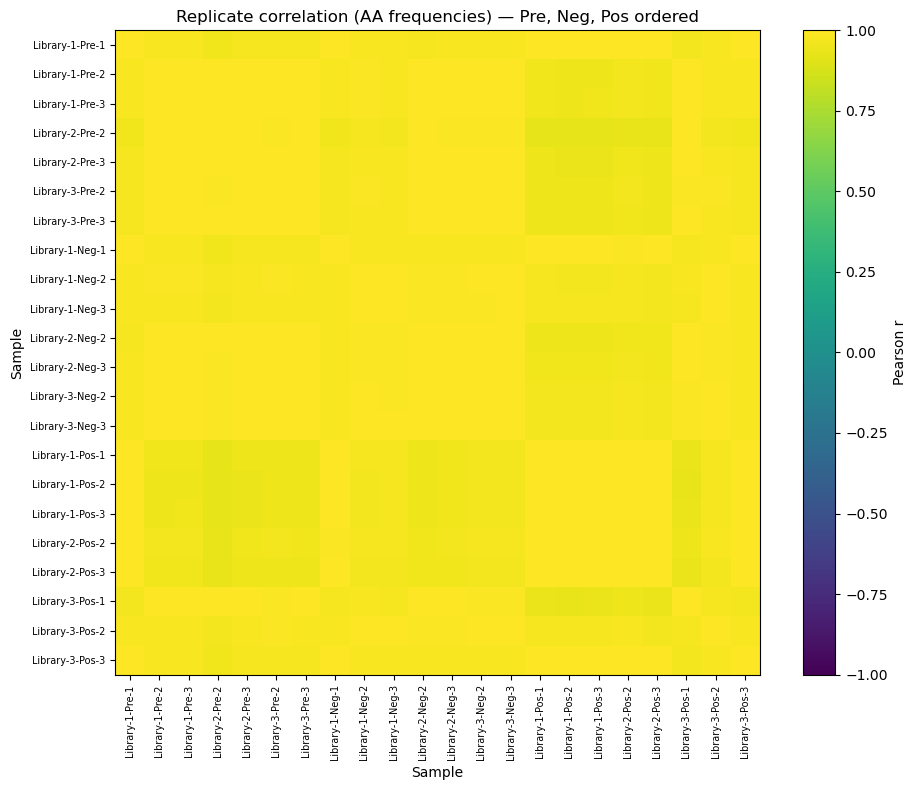

sample,Library-1-Pre-1,Library-1-Pre-2,Library-1-Pre-3,Library-2-Pre-2,Library-2-Pre-3,Library-3-Pre-2,Library-3-Pre-3,Library-1-Neg-1,Library-1-Neg-2,Library-1-Neg-3,...,Library-3-Neg-2,Library-3-Neg-3,Library-1-Pos-1,Library-1-Pos-2,Library-1-Pos-3,Library-2-Pos-2,Library-2-Pos-3,Library-3-Pos-1,Library-3-Pos-2,Library-3-Pos-3
sample,,,,,,,,,,,,,,,,,,,,,
Library-1-Pre-1,1.000000,0.977298,0.978012,0.958028,0.971887,0.975048,0.974224,0.999593,0.982178,0.982019,...,0.982379,0.982280,0.995355,0.994083,0.994931,0.994600,0.996158,0.966156,0.983026,0.999650
Library-1-Pre-2,0.977298,1.000000,0.999333,0.994421,0.998633,0.997477,0.999072,0.978035,0.985991,0.982158,...,0.996133,0.995823,0.953848,0.951729,0.952168,0.962755,0.956721,0.994949,0.983153,0.978428
Library-1-Pre-3,0.978012,0.999333,1.000000,0.993352,0.999090,0.996364,0.999400,0.979292,0.986669,0.983160,...,0.995825,0.996155,0.955133,0.952775,0.953955,0.962695,0.958406,0.995534,0.983998,0.979672
Library-2-Pre-2,0.958028,0.994421,0.993352,1.000000,0.996095,0.992114,0.995801,0.959914,0.970809,0.964559,...,0.987751,0.986962,0.928039,0.926424,0.926413,0.936258,0.931853,0.994352,0.965504,0.959945
Library-2-Pre-3,0.971887,0.998633,0.999090,0.996095,1.000000,0.996004,0.999457,0.973671,0.982364,0.978429,...,0.994092,0.994331,0.946322,0.944214,0.945152,0.953662,0.949933,0.996063,0.979036,0.974142
Library-3-Pre-2,0.975048,0.997477,0.996364,0.992114,0.996004,1.000000,0.996580,0.974662,0.985661,0.984237,...,0.996145,0.995670,0.952418,0.950890,0.949998,0.962219,0.953049,0.988417,0.984953,0.975594
Library-3-Pre-3,0.974224,0.999072,0.999400,0.995801,0.999457,0.996580,1.000000,0.975590,0.982800,0.979296,...,0.994761,0.994863,0.949334,0.947008,0.948103,0.956769,0.953032,0.995132,0.980178,0.975960
Library-1-Neg-1,0.999593,0.978035,0.979292,0.959914,0.973671,0.974662,0.975590,1.000000,0.981639,0.980695,...,0.982279,0.982419,0.994009,0.992570,0.994042,0.992167,0.995779,0.969008,0.981624,0.999889
Library-1-Neg-2,0.982178,0.985991,0.986669,0.970809,0.982364,0.985661,0.982800,0.981639,1.000000,0.997632,...,0.993792,0.994266,0.969054,0.967504,0.967726,0.974288,0.967121,0.978412,0.998099,0.982479


In [6]:
# Replicate correlation heatmap using the pre-filtered amino-acid frequency matrix
# used to generate the dissertation-facing AA correlation figure.

aa_freq_matrix = pd.read_csv(
    PROCESSED_DIR / "amino_acid_frequency_matrix_prefilter_dissertation_heatmap.csv",
    header=[0, 1],
    index_col=0
)

aa_freq_matrix.index.name = "sample"
aa_freq_matrix.columns.names = ["site", "aa"]

samples = aa_freq_matrix.index.tolist()

def sort_key(name: str):
    # Assumes names like "Library-1-Pre-2"
    parts = name.split("-")
    lib = int(parts[1])
    rep = int(parts[3])
    return (lib, rep)

pre_samples = sorted([s for s in samples if "-Pre-" in s], key=sort_key)
neg_samples = sorted([s for s in samples if "-Neg-" in s], key=sort_key)
pos_samples = sorted([s for s in samples if "-Pos-" in s], key=sort_key)

ordered_samples = pre_samples + neg_samples + pos_samples

aa_corr = aa_freq_matrix.T.corr()
aa_corr_reordered = aa_corr.loc[ordered_samples, ordered_samples]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    aa_corr_reordered,
    vmin=-1,
    vmax=1,
    cmap="viridis"
)

ax.set_xticks(range(len(ordered_samples)))
ax.set_yticks(range(len(ordered_samples)))
ax.set_xticklabels(ordered_samples, rotation=90, fontsize=7)
ax.set_yticklabels(ordered_samples, fontsize=7)

ax.set_title("Replicate correlation (AA frequencies) — Pre, Neg, Pos ordered")
ax.set_xlabel("Sample")
ax.set_ylabel("Sample")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson r")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "replicate_correlation_amino_acid_frequencies_prefilter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

aa_corr_reordered.to_csv(
    CHECKPOINT_DIR / "replicate_correlation_amino_acid_frequencies_prefilter.csv"
)

aa_corr_reordered

### Filtered/design-site amino-acid frequency heatmap comparison

This comparison heatmap is generated from `amino_acid_frequency_matrix_design_sites_filtered_heatmap.csv`.

It is retained to document how filtering/feature selection changes the amino-acid frequency correlation structure. This comparison heatmap is not treated as the dissertation-facing AA correlation figure.

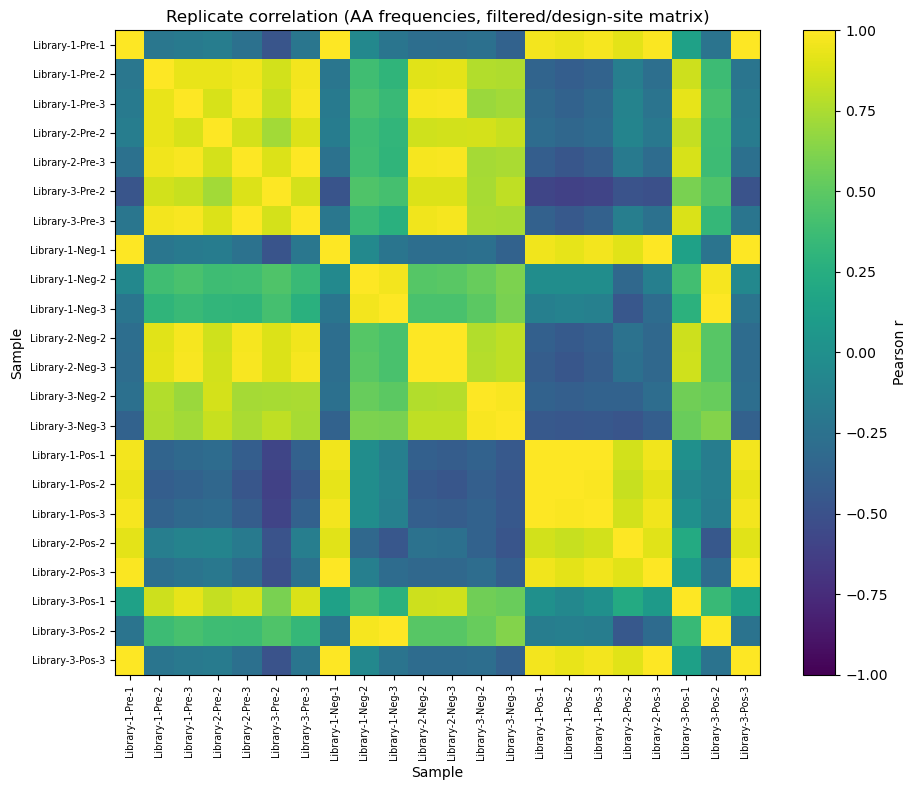

sample,Library-1-Pre-1,Library-1-Pre-2,Library-1-Pre-3,Library-2-Pre-2,Library-2-Pre-3,Library-3-Pre-2,Library-3-Pre-3,Library-1-Neg-1,Library-1-Neg-2,Library-1-Neg-3,...,Library-3-Neg-2,Library-3-Neg-3,Library-1-Pos-1,Library-1-Pos-2,Library-1-Pos-3,Library-2-Pos-2,Library-2-Pos-3,Library-3-Pos-1,Library-3-Pos-2,Library-3-Pos-3
sample,,,,,,,,,,,,,,,,,,,,,
Library-1-Pre-1,1.000000,-0.205738,-0.184156,-0.148893,-0.252622,-0.475765,-0.214628,0.997685,-0.065025,-0.224293,...,-0.262909,-0.367526,0.968270,0.937865,0.970122,0.916726,0.991689,0.140989,-0.231229,0.998832
Library-1-Pre-2,-0.205738,1.000000,0.935443,0.932955,0.954103,0.866530,0.966825,-0.215961,0.388065,0.307860,...,0.766761,0.765065,-0.353993,-0.404263,-0.365484,-0.145627,-0.268355,0.845360,0.371432,-0.222986
Library-1-Pre-3,-0.184156,0.935443,1.000000,0.875554,0.983809,0.831332,0.979300,-0.180962,0.425478,0.358446,...,0.702870,0.720715,-0.312983,-0.369792,-0.318804,-0.104899,-0.231512,0.929168,0.417771,-0.192684
Library-2-Pre-2,-0.148893,0.932955,0.875554,1.000000,0.871566,0.724877,0.898228,-0.157902,0.375252,0.316806,...,0.872819,0.834466,-0.289527,-0.333510,-0.301826,-0.100220,-0.200734,0.824100,0.377848,-0.167578
Library-2-Pre-3,-0.252622,0.954103,0.983809,0.871566,1.000000,0.894360,0.995721,-0.247362,0.390180,0.310999,...,0.733560,0.746888,-0.403510,-0.464758,-0.406754,-0.185592,-0.291869,0.875904,0.370975,-0.258855
Library-3-Pre-2,-0.475765,0.866530,0.831332,0.724877,0.894360,1.000000,0.869247,-0.479700,0.447979,0.409644,...,0.740949,0.808862,-0.583957,-0.615830,-0.588172,-0.486332,-0.513507,0.595552,0.450577,-0.485438
Library-3-Pre-3,-0.214628,0.966825,0.979300,0.898228,0.995721,0.869247,1.000000,-0.210697,0.355015,0.267207,...,0.742568,0.738781,-0.376460,-0.440919,-0.380614,-0.141248,-0.254302,0.889452,0.330573,-0.222004
Library-1-Neg-1,0.997685,-0.215961,-0.180962,-0.157902,-0.247362,-0.479700,-0.210697,1.000000,-0.059242,-0.224325,...,-0.264744,-0.372954,0.960546,0.925525,0.965077,0.910504,0.994533,0.147239,-0.231045,0.999657
Library-1-Neg-2,-0.065025,0.388065,0.425478,0.375252,0.390180,0.447979,0.355015,-0.059242,1.000000,0.966247,...,0.536837,0.605620,-0.021292,-0.021305,-0.015884,-0.325614,-0.134481,0.396111,0.971125,-0.070067


In [7]:
# Comparison heatmap using the filtered/design-site amino-acid frequency matrix.

aa_freq_matrix_filtered = pd.read_csv(
    PROCESSED_DIR / "amino_acid_frequency_matrix_design_sites_filtered_heatmap.csv",
    header=[0, 1],
    index_col=0
)

aa_freq_matrix_filtered.index.name = "sample"
aa_freq_matrix_filtered.columns.names = ["site", "aa"]

samples_filtered = aa_freq_matrix_filtered.index.tolist()

pre_samples_filtered = sorted([s for s in samples_filtered if "-Pre-" in s], key=sort_key)
neg_samples_filtered = sorted([s for s in samples_filtered if "-Neg-" in s], key=sort_key)
pos_samples_filtered = sorted([s for s in samples_filtered if "-Pos-" in s], key=sort_key)

ordered_samples_filtered = pre_samples_filtered + neg_samples_filtered + pos_samples_filtered

aa_corr_filtered = aa_freq_matrix_filtered.T.corr()
aa_corr_filtered_reordered = aa_corr_filtered.loc[
    ordered_samples_filtered,
    ordered_samples_filtered
]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    aa_corr_filtered_reordered,
    vmin=-1,
    vmax=1,
    cmap="viridis"
)

ax.set_xticks(range(len(ordered_samples_filtered)))
ax.set_yticks(range(len(ordered_samples_filtered)))
ax.set_xticklabels(ordered_samples_filtered, rotation=90, fontsize=7)
ax.set_yticklabels(ordered_samples_filtered, fontsize=7)

ax.set_title("Replicate correlation (AA frequencies, filtered/design-site matrix)")
ax.set_xlabel("Sample")
ax.set_ylabel("Sample")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson r")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "replicate_correlation_amino_acid_frequencies_design_sites_filtered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

aa_corr_filtered_reordered.to_csv(
    CHECKPOINT_DIR / "replicate_correlation_amino_acid_frequencies_design_sites_filtered.csv"
)

aa_corr_filtered_reordered

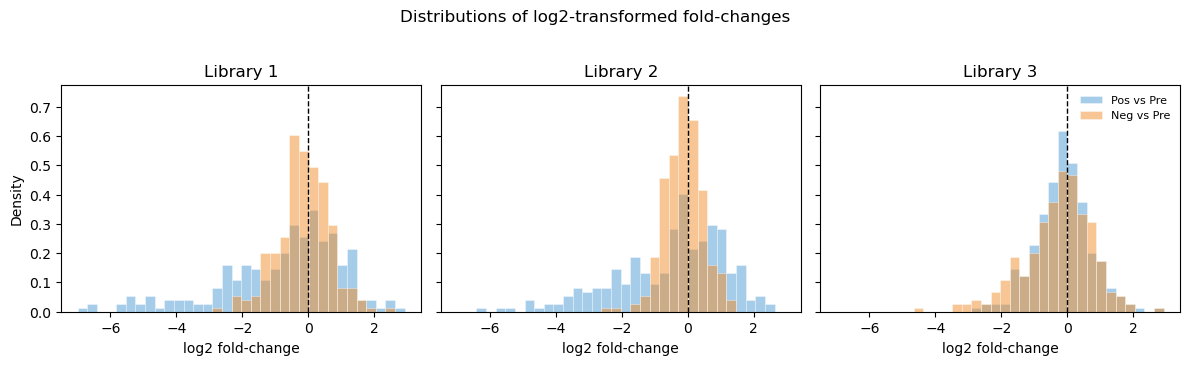

In [8]:
# Figure 3.6-style distribution plots:
# log2FC(Pos/Pre) and log2FC(Neg/Pre) distributions across the three libraries.

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

bins = np.linspace(
    min(landscape["log2fc_pos_pre"].min(), landscape["log2fc_neg_pre"].min()),
    max(landscape["log2fc_pos_pre"].max(), landscape["log2fc_neg_pre"].max()),
    35
)

for ax, library_id in zip(axes, sorted(landscape["library_id"].unique())):
    sub = landscape[landscape["library_id"] == library_id]

    ax.hist(
        sub["log2fc_pos_pre"],
        bins=bins,
        density=True,
        alpha=0.5,
        label="Pos vs Pre",
        color="#4C9BD4",
        edgecolor="white",
        linewidth=0.5,
    )

    ax.hist(
        sub["log2fc_neg_pre"],
        bins=bins,
        density=True,
        alpha=0.5,
        label="Neg vs Pre",
        color="#F28E2B",
        edgecolor="white",
        linewidth=0.5,
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")
    ax.set_title(f"Library {library_id}")
    ax.set_xlabel("log2 fold-change")

axes[0].set_ylabel("Density")
axes[-1].legend(frameon=False, fontsize=8)

fig.suptitle("Distributions of log2-transformed fold-changes", y=1.03)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_6_log2fc_distributions_pos_pre_neg_pre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

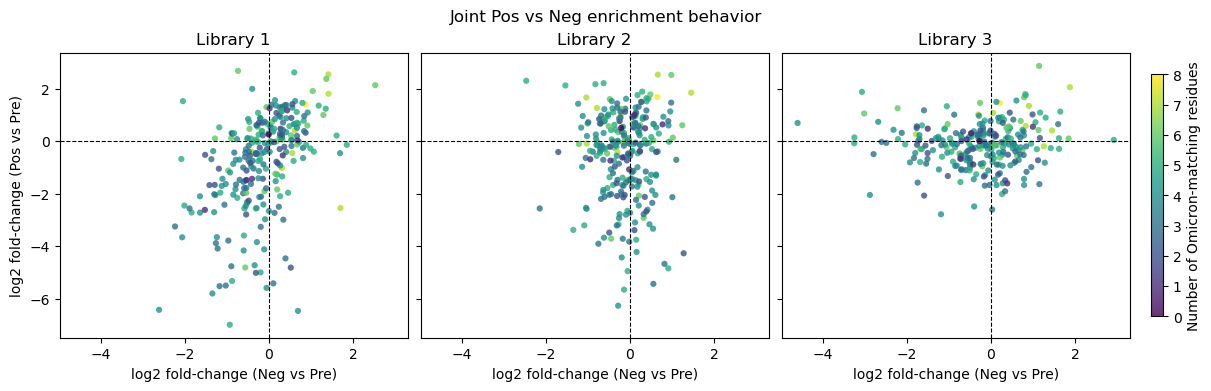

In [9]:
# Figure 3.8-style joint Pos-vs-Neg enrichment scatter plots.
# Each point is a genotype, colored by the number of Omicron-matching residues.

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3.8),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

vmin = landscape["mut_count"].min()
vmax = landscape["mut_count"].max()

scatter_handle = None

for ax, library_id in zip(axes, sorted(landscape["library_id"].unique())):
    sub = landscape[landscape["library_id"] == library_id]

    scatter_handle = ax.scatter(
        sub["log2fc_neg_pre"],
        sub["log2fc_pos_pre"],
        c=sub["mut_count"],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.8,
        s=20,
        edgecolors="none",
    )

    ax.axhline(0, linestyle="--", linewidth=0.8, color="black")
    ax.axvline(0, linestyle="--", linewidth=0.8, color="black")
    ax.set_title(f"Library {library_id}")
    ax.set_xlabel("log2 fold-change (Neg vs Pre)")

axes[0].set_ylabel("log2 fold-change (Pos vs Pre)")

cbar = fig.colorbar(
    scatter_handle,
    ax=axes,
    location="right",
    shrink=0.85,
    pad=0.02
)
cbar.set_label("Number of Omicron-matching residues")

fig.suptitle("Joint Pos vs Neg enrichment behavior")

fig.savefig(
    FIGURE_DIR / "figure_3_8_joint_pos_neg_enrichment_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
joint_quadrant_summary = landscape.copy()

joint_quadrant_summary["quadrant"] = np.select(
    [
        (joint_quadrant_summary["log2fc_pos_pre"] >= 0) & (joint_quadrant_summary["log2fc_neg_pre"] >= 0),
        (joint_quadrant_summary["log2fc_pos_pre"] >= 0) & (joint_quadrant_summary["log2fc_neg_pre"] < 0),
        (joint_quadrant_summary["log2fc_pos_pre"] < 0) & (joint_quadrant_summary["log2fc_neg_pre"] >= 0),
        (joint_quadrant_summary["log2fc_pos_pre"] < 0) & (joint_quadrant_summary["log2fc_neg_pre"] < 0),
    ],
    [
        "Pos enriched / Neg enriched",
        "Pos enriched / Neg depleted",
        "Pos depleted / Neg enriched",
        "Pos depleted / Neg depleted",
    ],
    default="Unclassified",
)

joint_quadrant_counts = (
    joint_quadrant_summary
    .groupby(["library_id", "quadrant"], as_index=False)
    .agg(n_genotypes=("wo", "size"))
    .sort_values(["library_id", "quadrant"])
)

joint_quadrant_counts.to_csv(
    CHECKPOINT_DIR / "dissertation_joint_pos_neg_quadrant_counts.csv",
    index=False
)

joint_quadrant_counts

,library_id,quadrant,n_genotypes
0,1,Pos depleted / Neg depleted,113
1,1,Pos depleted / Neg enriched,39
2,1,Pos enriched / Neg depleted,34
3,1,Pos enriched / Neg enriched,70
4,2,Pos depleted / Neg depleted,91
5,2,Pos depleted / Neg enriched,56
6,2,Pos enriched / Neg depleted,58
7,2,Pos enriched / Neg enriched,51
8,3,Pos depleted / Neg depleted,85
9,3,Pos depleted / Neg enriched,61


In [11]:
distribution_summary = (
    landscape
    .groupby("library_id", as_index=False)
    .agg(
        mean_log2fc_pos_pre=("log2fc_pos_pre", "mean"),
        median_log2fc_pos_pre=("log2fc_pos_pre", "median"),
        sd_log2fc_pos_pre=("log2fc_pos_pre", "std"),
        min_log2fc_pos_pre=("log2fc_pos_pre", "min"),
        max_log2fc_pos_pre=("log2fc_pos_pre", "max"),
        mean_log2fc_neg_pre=("log2fc_neg_pre", "mean"),
        median_log2fc_neg_pre=("log2fc_neg_pre", "median"),
        sd_log2fc_neg_pre=("log2fc_neg_pre", "std"),
        min_log2fc_neg_pre=("log2fc_neg_pre", "min"),
        max_log2fc_neg_pre=("log2fc_neg_pre", "max"),
    )
)

distribution_summary.to_csv(
    CHECKPOINT_DIR / "dissertation_log2fc_distribution_summary.csv",
    index=False
)

distribution_summary

,library_id,mean_log2fc_pos_pre,median_log2fc_pos_pre,sd_log2fc_pos_pre,min_log2fc_pos_pre,max_log2fc_pos_pre,mean_log2fc_neg_pre,median_log2fc_neg_pre,sd_log2fc_neg_pre,min_log2fc_neg_pre,max_log2fc_neg_pre
0,1,-0.781064,-0.400299,1.841111,-6.988549,2.677817,-0.147501,-0.146130,0.774948,-2.617260,2.528625
1,2,-0.528008,-0.170424,1.666116,-6.261104,2.534916,-0.123556,-0.120645,0.579552,-2.469786,1.456478
2,3,-0.139517,-0.128351,0.842288,-2.781378,2.864940,-0.283409,-0.176338,1.048862,-4.603787,2.921981


## Figure 3.9-style PCA of variant-level enrichment

This section performs PCA on genotype-level enrichment values within each library using `log2fc_pos_pre` and `log2fc_neg_pre`.

Each point represents one W/O genotype and is colored by mutational load.

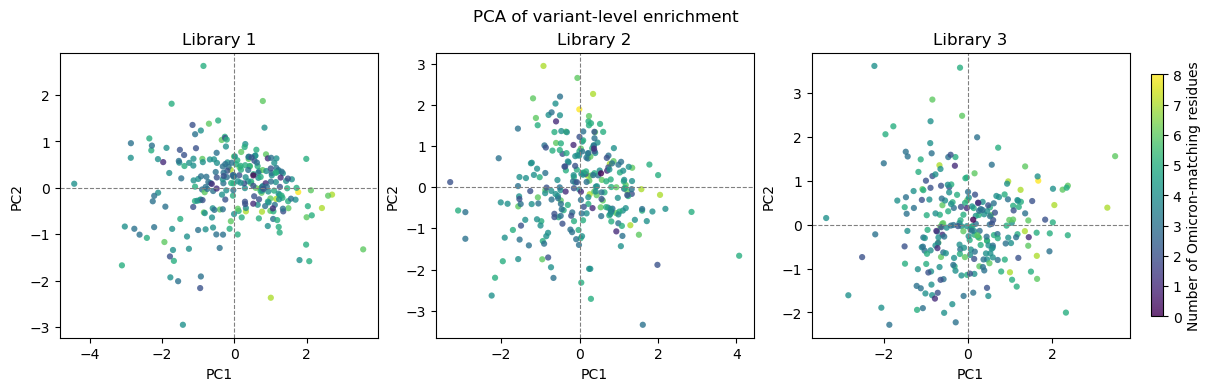

,library_id,pc1_variance_explained,pc2_variance_explained,pc1_loading_log2fc_pos_pre,pc1_loading_log2fc_neg_pre,pc2_loading_log2fc_pos_pre,pc2_loading_log2fc_neg_pre
0,1,0.734364,0.265636,0.707107,0.707107,0.707107,-0.707107
1,2,0.516140,0.483860,0.707107,-0.707107,0.707107,0.707107
2,3,0.531975,0.468025,0.707107,0.707107,0.707107,-0.707107


In [12]:
# Figure 3.9-style PCA of variant-level enrichment.
# PCA is performed separately for each library using two enrichment metrics:
# log2FC(Pos/Pre) and log2FC(Neg/Pre).

pca_summary_rows = []

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3.8),
    sharex=False,
    sharey=False,
    constrained_layout=True
)

vmin = landscape["mut_count"].min()
vmax = landscape["mut_count"].max()

scatter_handle = None

for ax, library_id in zip(axes, sorted(landscape["library_id"].unique())):
    sub = landscape[landscape["library_id"] == library_id].copy()

    X = sub[["log2fc_pos_pre", "log2fc_neg_pre"]].values
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)

    sub["PC1"] = pcs[:, 0]
    sub["PC2"] = pcs[:, 1]

    scatter_handle = ax.scatter(
        sub["PC1"],
        sub["PC2"],
        c=sub["mut_count"],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.8,
        s=20,
        edgecolors="none",
    )

    ax.axhline(0, linestyle="--", linewidth=0.8, color="gray")
    ax.axvline(0, linestyle="--", linewidth=0.8, color="gray")
    ax.set_title(f"Library {library_id}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    pca_summary_rows.append({
        "library_id": library_id,
        "pc1_variance_explained": pca.explained_variance_ratio_[0],
        "pc2_variance_explained": pca.explained_variance_ratio_[1],
        "pc1_loading_log2fc_pos_pre": pca.components_[0, 0],
        "pc1_loading_log2fc_neg_pre": pca.components_[0, 1],
        "pc2_loading_log2fc_pos_pre": pca.components_[1, 0],
        "pc2_loading_log2fc_neg_pre": pca.components_[1, 1],
    })

cbar = fig.colorbar(
    scatter_handle,
    ax=axes,
    location="right",
    shrink=0.85,
    pad=0.02
)
cbar.set_label("Number of Omicron-matching residues")

fig.suptitle("PCA of variant-level enrichment")

fig.savefig(
    FIGURE_DIR / "figure_3_9_pca_variant_level_enrichment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

pca_summary = pd.DataFrame(pca_summary_rows)

pca_summary.to_csv(
    CHECKPOINT_DIR / "figure_3_9_pca_variant_level_enrichment_summary.csv",
    index=False
)

pca_summary

In [13]:
mutational_load_summary = (
    landscape
    .groupby(["library_id", "mut_count"], as_index=False)
    .agg(
        mean_log2fc_pos_pre=("log2fc_pos_pre", "mean"),
        sd_log2fc_pos_pre=("log2fc_pos_pre", "std"),
        mean_log2fc_neg_pre=("log2fc_neg_pre", "mean"),
        sd_log2fc_neg_pre=("log2fc_neg_pre", "std"),
        mean_ddelta=("ddelta", "mean"),
        sd_ddelta=("ddelta", "std"),
        n_genotypes=("wo", "size")
    )
)

mutational_load_summary.to_csv(
    CHECKPOINT_DIR / "dissertation_mutational_load_summary.csv",
    index=False
)

mutational_load_summary.head(20)

,library_id,mut_count,mean_log2fc_pos_pre,sd_log2fc_pos_pre,mean_log2fc_neg_pre,sd_log2fc_neg_pre,mean_ddelta,sd_ddelta,n_genotypes
0,1,0,0.253572,NaN,-0.005690,NaN,0.259262,NaN,1
1,1,1,-0.391114,1.379329,-0.092257,0.711266,-0.298857,0.903527,8
2,1,2,-0.759975,1.530385,-0.218827,0.622052,-0.541148,1.510677,28
3,1,3,-1.312145,1.856823,-0.333162,0.663760,-0.978982,1.621195,56
4,1,4,-1.096031,2.012844,-0.281362,0.744626,-0.814669,1.773891,70
5,1,5,-0.477661,1.786910,-0.028474,0.875275,-0.449187,1.655273,56
6,1,6,-0.026452,1.594720,0.083640,0.816904,-0.110092,1.442777,28
7,1,7,0.061617,1.593240,0.730691,0.721113,-0.669074,1.633468,8
8,1,8,1.401357,NaN,0.870073,NaN,0.531285,NaN,1
9,2,0,0.507641,NaN,-0.210163,NaN,0.717804,NaN,1


In [14]:
# Table 3.4-style statistical summary of mutational-load analysis.
#
# Pearson correlations are calculated across mutational-load mean Pos/Pre
# enrichment values. Each library is represented by 9 mean values, one for
# each mutational-load class from 0 to 8.
#
# Mann–Whitney tests compare genotype-level Pos/Pre enrichment values for
# mutational load 8 versus all other genotypes within each library.

table_3_4_rows = []

# Pairwise Pearson correlations across mutational-load mean Pos/Pre values.
pos_load_wide = (
    mutational_load_summary
    .pivot(index="mut_count", columns="library_id", values="mean_log2fc_pos_pre")
    .rename(columns=lambda x: f"Lib{x}")
)

library_pairs = [
    ("Lib1", "Lib2"),
    ("Lib1", "Lib3"),
    ("Lib2", "Lib3"),
]

for lib_a, lib_b in library_pairs:
    valid = pos_load_wide[[lib_a, lib_b]].dropna()
    r_value, p_value = pearsonr(valid[lib_a], valid[lib_b])

    table_3_4_rows.append({
        "Comparison": f"Pearson r ({lib_a} vs {lib_b}, Pos)",
        "Statistic": "r",
        "Value": r_value,
        "p_value": p_value,
        "Formatted": f"{r_value:.3f} (p = {p_value:.2e})",
        "n_values": valid.shape[0],
        "calculation_note": "Pearson correlation across mutational-load mean Pos/Pre enrichment values",
    })

# Mann–Whitney comparisons: mutational load 8 vs all other genotypes.
for library_id in sorted(landscape["library_id"].unique()):
    sub = landscape[landscape["library_id"] == library_id]

    load_8 = sub.loc[sub["mut_count"] == 8, "log2fc_pos_pre"]
    other_loads = sub.loc[sub["mut_count"] != 8, "log2fc_pos_pre"]

    stat, p_value = mannwhitneyu(
        load_8,
        other_loads,
        alternative="two-sided"
    )

    table_3_4_rows.append({
        "Comparison": f"Load 8 vs others (Pos, Lib{library_id})",
        "Statistic": "Mann–Whitney p",
        "Value": p_value,
        "p_value": p_value,
        "Formatted": f"{p_value:.3g}",
        "n_values": f"{load_8.shape[0]} vs {other_loads.shape[0]}",
        "calculation_note": "Mann–Whitney U test comparing genotype-level Pos/Pre enrichment for load 8 versus all other genotypes",
    })

table_3_4 = pd.DataFrame(table_3_4_rows)

table_3_4.to_csv(
    CHECKPOINT_DIR / "table_3_4_mutational_load_statistics.csv",
    index=False
)

table_3_4_display = table_3_4[["Comparison", "Statistic", "Formatted"]].rename(
    columns={"Formatted": "Value"}
)

table_3_4_display.to_csv(
    CHECKPOINT_DIR / "table_3_4_mutational_load_statistics_display.csv",
    index=False
)

table_3_4_display

,Comparison,Statistic,Value
0,"Pearson r (Lib1 vs Lib2, Pos)",r,0.946 (p = 1.17e-04)
1,"Pearson r (Lib1 vs Lib3, Pos)",r,0.885 (p = 1.49e-03)
2,"Pearson r (Lib2 vs Lib3, Pos)",r,0.910 (p = 6.47e-04)
3,"Load 8 vs others (Pos, Lib1)",Mann–Whitney p,0.109
4,"Load 8 vs others (Pos, Lib2)",Mann–Whitney p,0.0859
5,"Load 8 vs others (Pos, Lib3)",Mann–Whitney p,0.0781


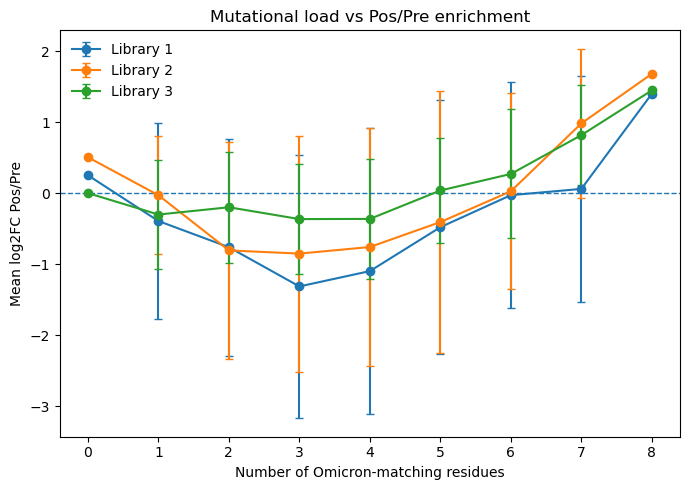

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for library_id, group in mutational_load_summary.groupby("library_id"):
    group = group.sort_values("mut_count")
    ax.errorbar(
        group["mut_count"],
        group["mean_log2fc_pos_pre"],
        yerr=group["sd_log2fc_pos_pre"],
        marker="o",
        capsize=3,
        label=f"Library {library_id}"
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Number of Omicron-matching residues")
ax.set_ylabel("Mean log2FC Pos/Pre")
ax.set_title("Mutational load vs Pos/Pre enrichment")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "mutational_load_pos_pre.png", dpi=300)
plt.show()

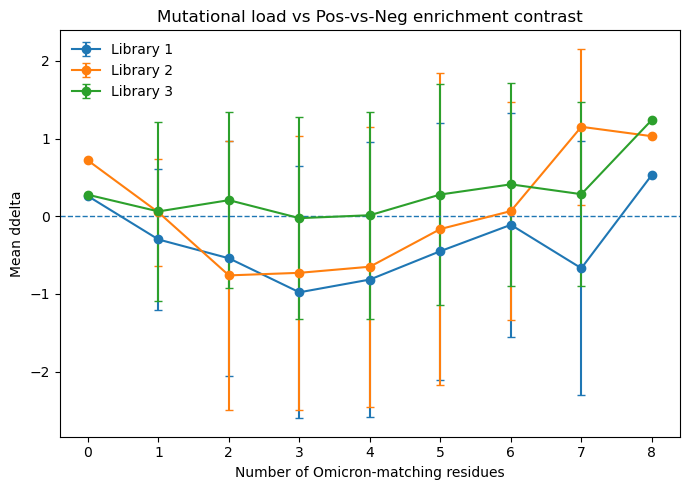

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

for library_id, group in mutational_load_summary.groupby("library_id"):
    group = group.sort_values("mut_count")
    ax.errorbar(
        group["mut_count"],
        group["mean_ddelta"],
        yerr=group["sd_ddelta"],
        marker="o",
        capsize=3,
        label=f"Library {library_id}"
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Number of Omicron-matching residues")
ax.set_ylabel("Mean ddelta")
ax.set_title("Mutational load vs Pos-vs-Neg enrichment contrast")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "mutational_load_ddelta.png", dpi=300)
plt.show()

In [17]:
def pairwise_library_correlations(
    df: pd.DataFrame,
    value_col: str
) -> pd.DataFrame:
    wide = (
        df
        .pivot(index="wo", columns="library_id", values=value_col)
        .rename(columns=lambda x: f"Library_{x}")
    )
    
    rows = []
    libraries = list(wide.columns)
    
    for i, lib_a in enumerate(libraries):
        for lib_b in libraries[i + 1:]:
            valid = wide[[lib_a, lib_b]].dropna()
            rows.append({
                "metric": value_col,
                "library_a": lib_a,
                "library_b": lib_b,
                "n_genotypes": valid.shape[0],
                "pearson_r": valid[lib_a].corr(valid[lib_b], method="pearson"),
                "spearman_r": valid[lib_a].corr(valid[lib_b], method="spearman"),
            })
    
    return pd.DataFrame(rows)

correlation_summary = pd.concat(
    [
        pairwise_library_correlations(landscape, "log2fc_pos_pre"),
        pairwise_library_correlations(landscape, "log2fc_neg_pre"),
        pairwise_library_correlations(landscape, "ddelta"),
    ],
    ignore_index=True
)

correlation_summary.to_csv(
    CHECKPOINT_DIR / "dissertation_pairwise_library_correlations.csv",
    index=False
)

correlation_summary

,metric,library_a,library_b,n_genotypes,pearson_r,spearman_r
0,log2fc_pos_pre,Library_1,Library_2,256,0.851315,0.862185
1,log2fc_pos_pre,Library_1,Library_3,256,0.595404,0.632746
2,log2fc_pos_pre,Library_2,Library_3,256,0.628046,0.626657
3,log2fc_neg_pre,Library_1,Library_2,256,0.069201,0.020220
4,log2fc_neg_pre,Library_1,Library_3,256,0.092144,0.122312
5,log2fc_neg_pre,Library_2,Library_3,256,0.161092,0.104927
6,ddelta,Library_1,Library_2,256,0.667204,0.632463
7,ddelta,Library_1,Library_3,256,0.194780,0.217777
8,ddelta,Library_2,Library_3,256,0.385355,0.406043


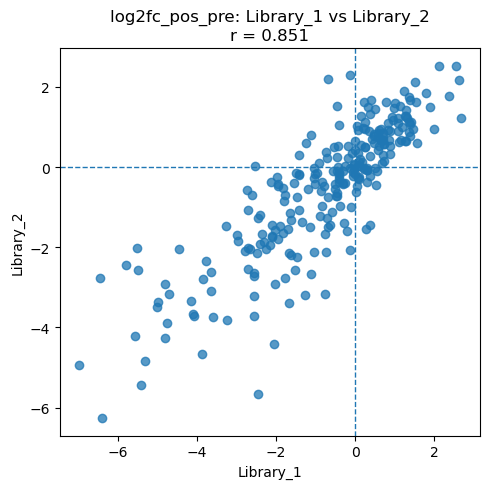

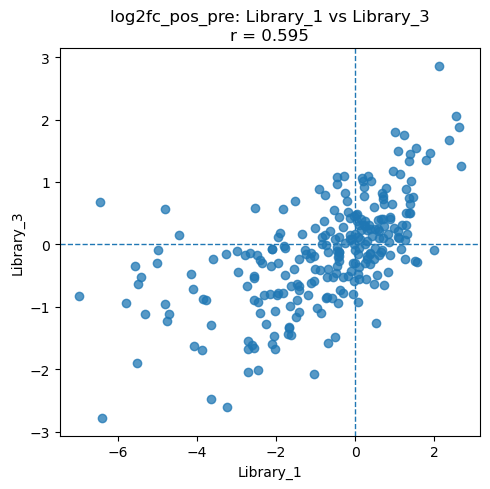

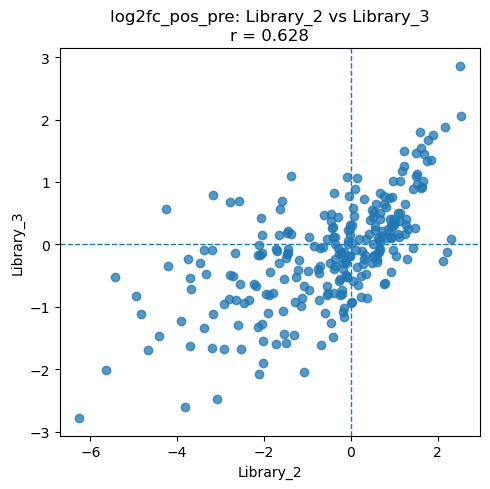

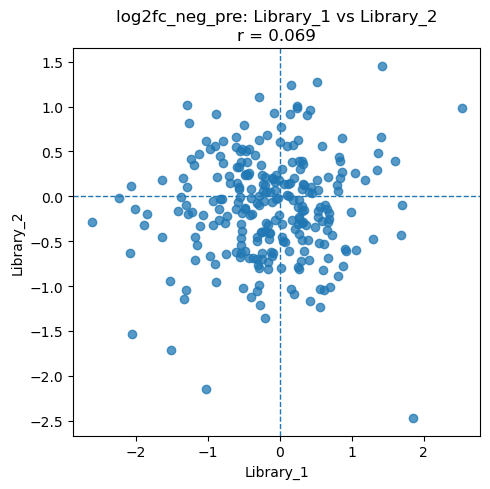

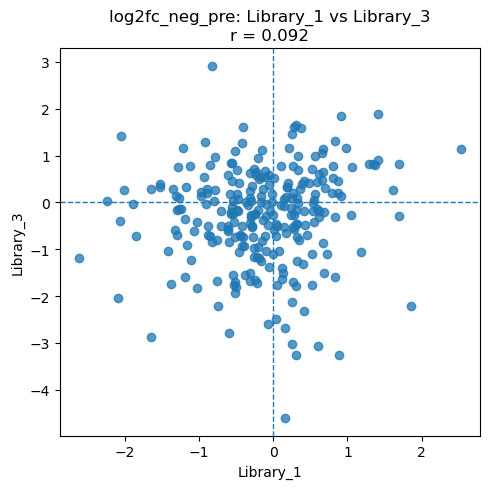

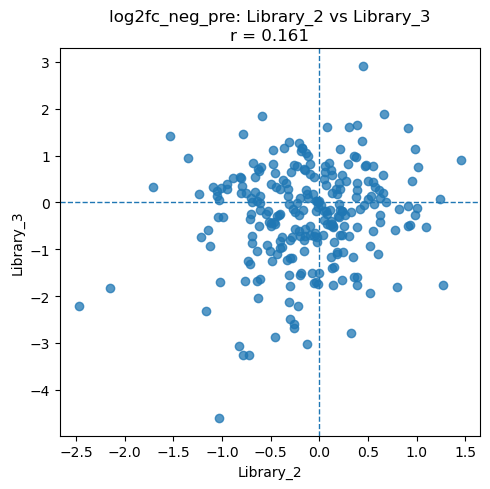

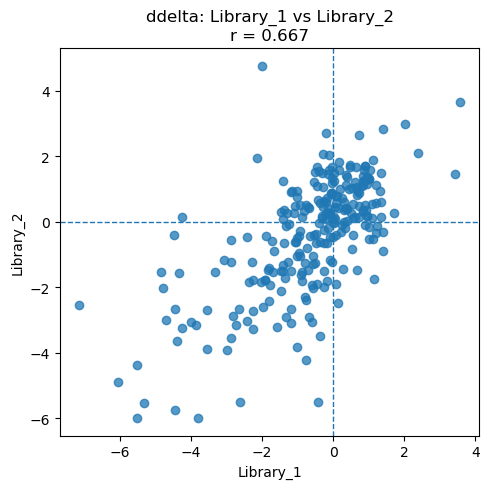

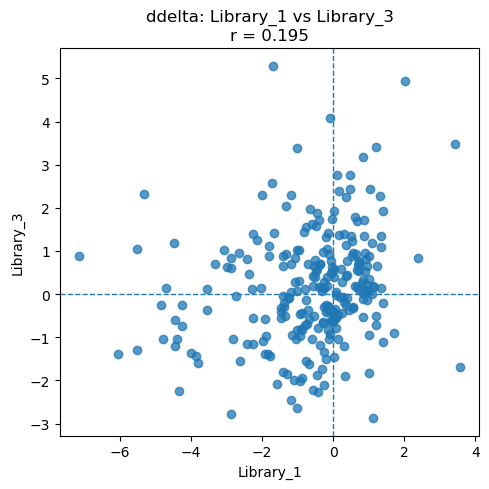

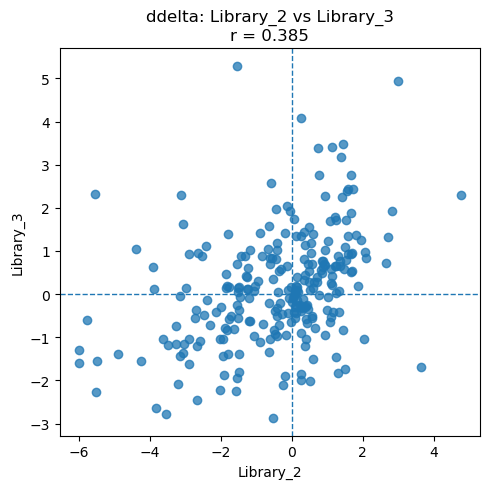

In [18]:
for metric in ["log2fc_pos_pre", "log2fc_neg_pre", "ddelta"]:
    wide = (
        landscape
        .pivot(index="wo", columns="library_id", values=metric)
        .rename(columns=lambda x: f"Library_{x}")
    )
    
    pairs = [("Library_1", "Library_2"), ("Library_1", "Library_3"), ("Library_2", "Library_3")]
    
    for x_col, y_col in pairs:
        valid = wide[[x_col, y_col]].dropna()
        r = valid[x_col].corr(valid[y_col])
        
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(valid[x_col], valid[y_col], alpha=0.75)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{metric}: {x_col} vs {y_col}\nr = {r:.3f}")
        
        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / f"correlation_{metric}_{x_col}_vs_{y_col}.png",
            dpi=300
        )
        plt.show()

In [19]:
print("Negative cutoff:", DDELTA_NEGATIVE_CUTOFF)
print("Positive cutoff:", DDELTA_POSITIVE_CUTOFF)
print("Q-value cutoff:", QVALUE_CUTOFF)

def assign_display_category(row):
    """
    Categorize each genotype for plotting.
    """
    is_significant = row["q_pos_neg"] <= QVALUE_CUTOFF

    if not is_significant:
        return "Insignificant"
    elif row["ddelta"] <= DDELTA_NEGATIVE_CUTOFF:
        return "Negative significant"
    elif row["ddelta"] >= DDELTA_POSITIVE_CUTOFF:
        return "Positive significant"
    else:
        return "Neutral significant"

DISPLAY_CATEGORY_ORDER = [
    "Insignificant",
    "Neutral significant",
    "Negative significant",
    "Positive significant",
]

DISPLAY_CATEGORY_COLORS = {
    "Negative significant": "#d62728",   # red
    "Neutral significant": "#f5a623",    # orange-yellow
    "Positive significant": "#2ca25f",   # green
    "Insignificant": "#9ecae1",          # light blue
}

volcano_source = volcano_source.copy()
volcano_source["display_category"] = volcano_source.apply(assign_display_category, axis=1)

volcano_source[["library_id", "wo", "ddelta", "q_pos_neg", "display_category"]].head()

Negative cutoff: -1.0
Positive cutoff: 1.0
Q-value cutoff: 0.05


,library_id,wo,ddelta,q_pos_neg,display_category
0,1,OOOOOOOO,0.531285,0.000000,Neutral significant
1,1,OOOOOOOW,0.016124,0.092685,Insignificant
2,1,OOOOOOWO,-1.324413,0.000000,Negative significant
3,1,OOOOOOWW,-4.241921,0.000000,Negative significant
4,1,OOOOOWOO,-1.003995,0.000000,Negative significant


In [20]:
volcano_category_summary = (
    volcano_source
    .groupby(["library_id", "display_category"], as_index=False)
    .agg(
        n_genotypes=("wo", "size"),
        mean_ddelta=("ddelta", "mean"),
        median_ddelta=("ddelta", "median"),
        min_ddelta=("ddelta", "min"),
        max_ddelta=("ddelta", "max"),
    )
    .sort_values(["library_id", "display_category"])
)

volcano_category_summary.to_csv(
    CHECKPOINT_DIR / "dissertation_volcano_category_summary.csv",
    index=False
)

volcano_category_summary

,library_id,display_category,n_genotypes,mean_ddelta,median_ddelta,min_ddelta,max_ddelta
0,1,Insignificant,3,0.001702,-0.000420,-0.010597,0.016124
1,1,Negative significant,81,-2.491912,-1.975832,-7.149398,-1.003995
2,1,Neutral significant,147,0.016671,-0.030723,-0.971736,0.997293
3,1,Positive significant,25,1.487885,1.238939,1.000727,3.575571
4,2,Insignificant,2,-0.000091,-0.000091,-0.003339,0.003157
5,2,Negative significant,84,-2.475436,-2.002291,-5.986312,-1.034171
6,2,Neutral significant,115,0.120485,0.165399,-0.948157,0.995405
7,2,Positive significant,55,1.646206,1.488899,1.014532,4.770095
8,3,Insignificant,2,-0.020951,-0.020951,-0.040202,-0.001700
9,3,Negative significant,47,-1.617091,-1.502927,-2.871160,-1.030251


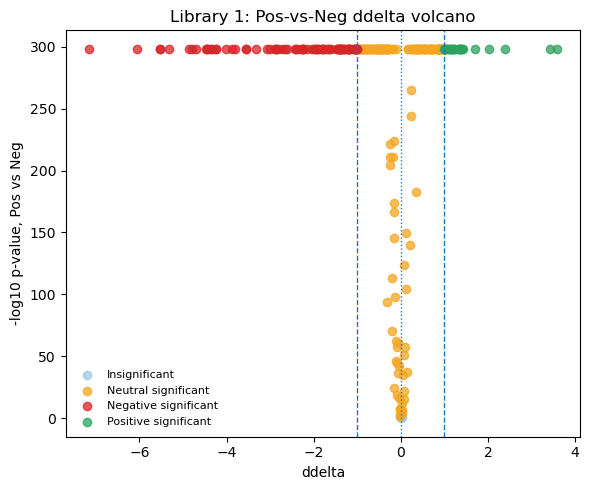

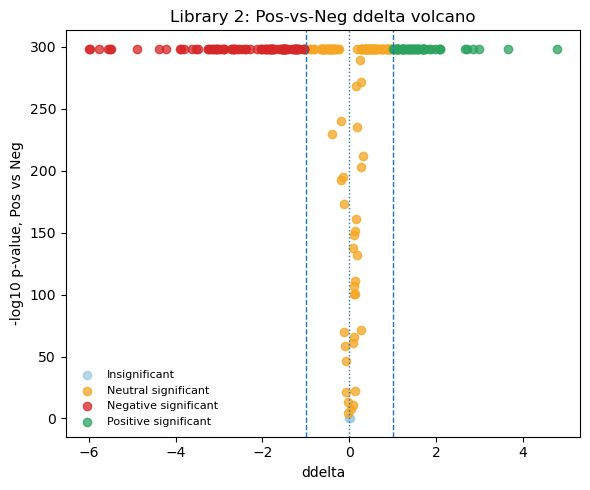

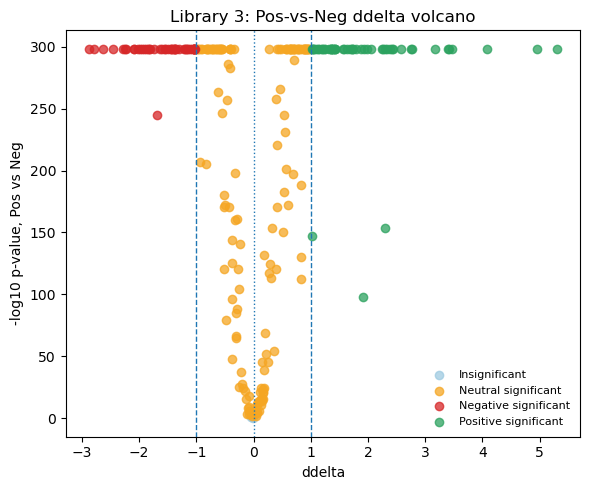

In [21]:
for library_id, group in volcano_source.groupby("library_id"):
    fig, ax = plt.subplots(figsize=(6, 5))

    for category in DISPLAY_CATEGORY_ORDER:
        sub = group[group["display_category"] == category]
        if sub.empty:
            continue

        ax.scatter(
            sub["ddelta"],
            sub["neglog10_p_pos_neg"],
            alpha=0.75,
            label=category,
            color=DISPLAY_CATEGORY_COLORS[category]
        )

    ax.axvline(DDELTA_NEGATIVE_CUTOFF, linestyle="--", linewidth=1)
    ax.axvline(DDELTA_POSITIVE_CUTOFF, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle=":", linewidth=1)

    ax.set_xlabel("ddelta")
    ax.set_ylabel("-log10 p-value, Pos vs Neg")
    ax.set_title(f"Library {library_id}: Pos-vs-Neg ddelta volcano")
    ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"volcano_ddelta_category_colored_library_{library_id}.png",
        dpi=300
    )
    plt.show()

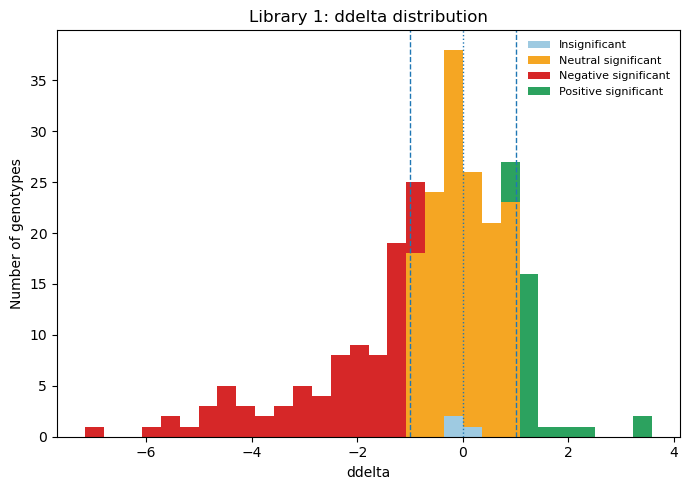

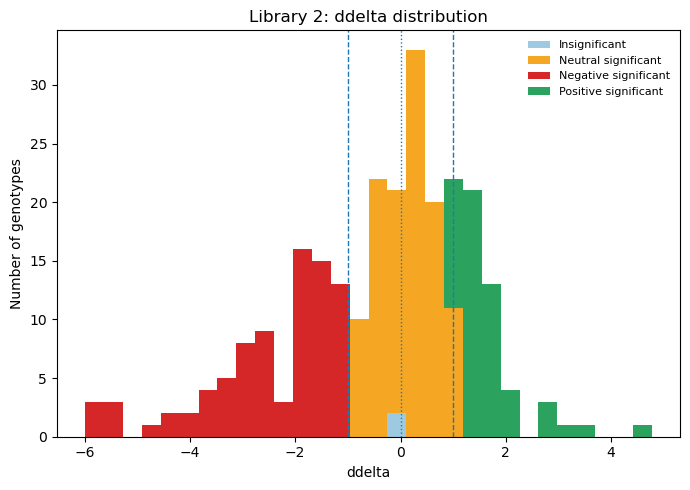

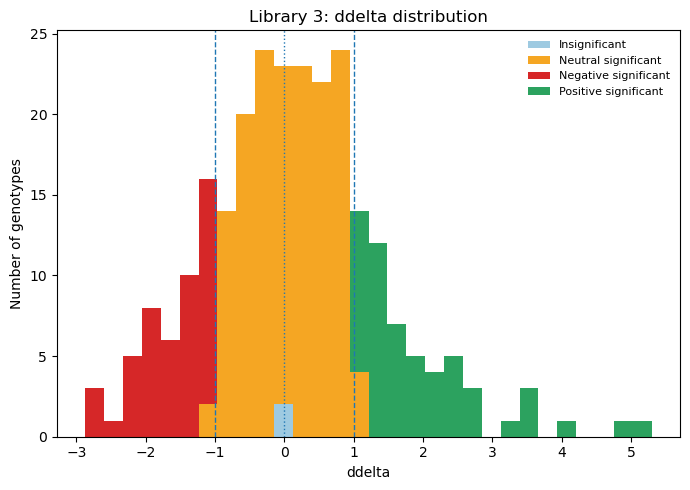

,library_id,n_genotypes,n_negative_significant,n_neutral_significant,n_positive_significant,n_insignificant
0,1,256,81,147,25,3
1,2,256,84,115,55,2
2,3,256,47,154,53,2


In [22]:
histogram_summary_rows = []

for library_id, group in volcano_source.groupby("library_id"):
    fig, ax = plt.subplots(figsize=(7, 5))

    data_by_category = []
    colors = []

    for category in DISPLAY_CATEGORY_ORDER:
        sub = group[group["display_category"] == category]
        if sub.empty:
            continue
        data_by_category.append(sub["ddelta"].dropna().values)
        colors.append(DISPLAY_CATEGORY_COLORS[category])

    ax.hist(
        data_by_category,
        bins=30,
        stacked=True,
        color=colors,
        label=[cat for cat in DISPLAY_CATEGORY_ORDER if not group[group["display_category"] == cat].empty]
    )

    ax.axvline(DDELTA_NEGATIVE_CUTOFF, linestyle="--", linewidth=1)
    ax.axvline(DDELTA_POSITIVE_CUTOFF, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle=":", linewidth=1)

    ax.set_xlabel("ddelta")
    ax.set_ylabel("Number of genotypes")
    ax.set_title(f"Library {library_id}: ddelta distribution")
    ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"histogram_ddelta_category_colored_library_{library_id}.png",
        dpi=300
    )
    plt.show()

    histogram_summary_rows.append({
        "library_id": library_id,
        "n_genotypes": group.shape[0],
        "n_negative_significant": int((group["display_category"] == "Negative significant").sum()),
        "n_neutral_significant": int((group["display_category"] == "Neutral significant").sum()),
        "n_positive_significant": int((group["display_category"] == "Positive significant").sum()),
        "n_insignificant": int((group["display_category"] == "Insignificant").sum()),
    })

histogram_summary = pd.DataFrame(histogram_summary_rows)

histogram_summary.to_csv(
    CHECKPOINT_DIR / "dissertation_ddelta_histogram_summary.csv",
    index=False
)

histogram_summary

In [24]:
figure_outputs = sorted(FIGURE_DIR.glob("*.png"))

figure_inventory = pd.DataFrame({
    "figure_file": [path.name for path in figure_outputs],
    "relative_path": [str(path.relative_to(PROJECT_ROOT)) for path in figure_outputs],
})

figure_inventory.to_csv(
    CHECKPOINT_DIR / "dissertation_figure_inventory.csv",
    index=False
)

figure_inventory

,figure_file,relative_path
0,correlation_ddelta_Library_1_vs_Library_2.png,figures/dissertation/correlation_ddelta_Librar...
1,correlation_ddelta_Library_1_vs_Library_3.png,figures/dissertation/correlation_ddelta_Librar...
2,correlation_ddelta_Library_2_vs_Library_3.png,figures/dissertation/correlation_ddelta_Librar...
3,correlation_log2fc_neg_pre_Library_1_vs_Librar...,figures/dissertation/correlation_log2fc_neg_pr...
4,correlation_log2fc_neg_pre_Library_1_vs_Librar...,figures/dissertation/correlation_log2fc_neg_pr...
5,correlation_log2fc_neg_pre_Library_2_vs_Librar...,figures/dissertation/correlation_log2fc_neg_pr...
6,correlation_log2fc_pos_pre_Library_1_vs_Librar...,figures/dissertation/correlation_log2fc_pos_pr...
7,correlation_log2fc_pos_pre_Library_1_vs_Librar...,figures/dissertation/correlation_log2fc_pos_pr...
8,correlation_log2fc_pos_pre_Library_2_vs_Librar...,figures/dissertation/correlation_log2fc_pos_pr...
9,figure_3_6_log2fc_distributions_pos_pre_neg_pr...,figures/dissertation/figure_3_6_log2fc_distrib...


## Figure/table reproduction summary

This notebook generates core dissertation-associated summary tables and figures from the processed W/O landscape tables and related processed frequency matrices.

Generated summary tables include:

- library-level enrichment summaries
- log2FC distribution summaries
- joint Pos-vs-Neg quadrant summaries
- PCA variance/loading summaries
- mutational-load summaries
- Table 3.4-style mutational-load statistical summaries
- pairwise library correlation summaries
- volcano category summaries
- ddelta histogram category summaries
- generated figure inventory

Generated figures include:

- replicate-level genotype frequency correlation heatmap
- dissertation-facing replicate-level amino-acid frequency correlation heatmap
- filtered/design-site amino-acid frequency correlation comparison heatmap
- Figure 3.6-style log2FC distribution plots for Pos/Pre and Neg/Pre
- Figure 3.8-style joint Pos-vs-Neg enrichment scatter plots colored by mutational load
- Figure 3.9-style PCA plots of variant-level enrichment
- mutational-load trends for Pos/Pre enrichment
- mutational-load trends for `ddelta`
- library-to-library reproducibility scatter plots
- Pos-vs-Neg `ddelta` volcano plots with category coloring
- `ddelta` distribution histograms with category coloring

The Table 3.4-style Pearson correlations are calculated across mutational-load mean Pos/Pre enrichment values, while the Mann–Whitney tests compare genotype-level Pos/Pre enrichment for mutational load 8 versus all other genotypes.

Specialized 3D landscape, network/path, and collaborator model-comparison analyses are intentionally handled separately.